In [1]:
# Repo-root bootstrap: find the directory containing the `llm_perf` package
# (walking up from CWD) and chdir there so paths like "llm_perf/database/..."
# and "assets/..." resolve regardless of where the notebook lives on disk.
import os
from pathlib import Path
_p = Path.cwd()
while not (_p / "llm_perf" / "__init__.py").exists():
    if _p == _p.parent:
        raise RuntimeError("Could not find llm_perf repo root from " + str(Path.cwd()))
    _p = _p.parent
os.chdir(_p)
print("cwd:", Path.cwd())

cwd: /Users/jasonlu/Projects/ai.cluster/llm_perf


# Pareto Frontier vs. Cluster Size

**Question:** as the cluster grows from 64 to 1024 GPUs (per-device hardware held fixed), how does the (throughput/GPU, interactivity) Pareto frontier shift? Which partitions win at each size, and why?

**Setup:** GPT-1.8T MoE @ FP4 on GB200-class devices (192 GB HBM @ 8 TB/s, 9000 TF, 900 GB/s · 0.5 μs scale-up, held uniform as we scale `num_devices` — a hypothetical sweep that ignores real-world scale-out fabric changes beyond the 72-GPU NVL72 rack). For each `N ∈ {64, 128, 256, 512, 1024}`:

1. Enumerate every valid `(PP, TP, EP, SP)` partition with `PP·TP·EP·SP ≤ N`.
2. For each partition, sweep `B` up to the KV-paging max.
3. Extract the upper-right envelope in (throughput/GPU, interactivity) space.

**Constraints for this model + the operational cap:**

- **`PP ≤ 8`** — operational cap (`PP_MAX = 8` in cell #5). The library default is 32; this notebook pins 8 for the typical PP-capped operational regime where pipeline bubble cost / latency budget / microbatch-floor make deeper PP impractical.
- `TP ≤ min(n_kv=16, n_experts=16) = 16` — capped by GQA replication and expert count (powers-of-2 ladder).
- `EP ≤ n_experts = 16` — capped by expert count (powers-of-2 ladder).
- `TP · EP ≤ scale_up_domain` — keeps heavy intra-layer collectives rack-local.
- `PP · TP · EP · SP ≤ N` — cluster-fit cap (varies per `N`).

Under the PP=8 cap, scaling levers that activate as `N` grows are TP (up to 16), EP (up to 16), and DP — not PP. Raise `PP_MAX` in cell #5 to compare against the unbounded-PP regime.

**Why per-GPU metrics aren't trivially invariant.** Naively, adding more devices = more DP replicas, and per-GPU throughput should be flat. But `DP = N // (PP·TP·EP·SP)` is floored — if `N` isn't a clean multiple of the replica size, leftover devices sit idle and drag down `TTPS / N`. The competition between partition shapes is partly a **device-utilization** competition.

## 1. Imports and spec loading

In [2]:
from __future__ import annotations

import math
from copy import deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt

from llm_perf import InferenceCalculator
from llm_perf.core.kv_paging_model import KVPagingConfig, compute_kv_paging
from llm_perf.core.memory_model import compute_memory
from llm_perf.io import load_model_spec, load_system_spec, load_tuning_spec
from llm_perf.specs.partition_spec import PartitionSpec
from llm_perf.specs.system_spec import span_tiers

MODEL = "llm_perf/database/model/gpt_1_8t_moe.json"
SYSTEM = "llm_perf/database/system/gb200.72gpu.json"
TUNER = "llm_perf/database/tuner/gpt_1_8t_moe.tuner.json"

S_DECODE = 8192
BPP_FP4 = 0.5

CLUSTER_SIZES = [64, 128, 256, 512, 1024]

model = load_model_spec(MODEL)
model.bytes_per_param = BPP_FP4
base_system = load_system_spec(SYSTEM)
tuner_base = load_tuning_spec(TUNER)
tuner_base.S_decode = S_DECODE
tuner_base.B_decode = 1

up_alpha, up_bw, _ = span_tiers(base_system.get_tier_chain('TP'), 2)
print(f"Model:   {model.name}  L={model.L}  H={model.H}  n_kv={model.n_kv}  b={model.bytes_per_param}")
print(f"Device:  HBM={base_system.device.hbm_bandwidth_GBps:.0f} GB/s  "
      f"peak={base_system.device.peak_flops_TF:.0f} TF  "
      f"scale-up={up_bw:.0f} GB/s · {up_alpha:.2f} μs")
print(f"Cluster sizes: {CLUSTER_SIZES}")

Model:   GPT-1.8T-MoE  L=120  H=20480  n_kv=16  b=0.5
Device:  HBM=8000 GB/s  peak=2250 TF  scale-up=900 GB/s · 0.50 μs
Cluster sizes: [64, 128, 256, 512, 1024]


## 2. Partition enumeration and sweep helpers

Operational PP cap: **`PP_MAX = 8`** (matches `pareto_basic`). The library default is 32; this notebook pins 8 to match the typical PP-capped operational regime where pipeline bubble cost / latency budget / microbatch-floor make deeper PP impractical. TP and EP are capped by the model (`n_kv = n_experts = 16`). To compare against the deeper-PP frontier, raise `PP_MAX` in cell #5.


In [3]:
from llm_perf.utils import (
    enumerate_partitions as _enumerate_partitions,
    describe_constraints,
)

PP_MAX = 8   # Operational cap; raise to 32 to match unbounded-PP analysis.

print(describe_constraints(model, base_system, pp_max=PP_MAX))


@dataclass
class Point:
    N: int
    partition: PartitionSpec
    B: int
    tput_per_gpu: float
    interactivity: float
    TPOT_ms: float

    @property
    def part_label(self) -> str:
        p = self.partition
        return f"PP={p.PP} TP={p.TP} EP={p.EP} SP={p.SP}"

    @property
    def replica(self) -> int:
        p = self.partition
        return p.PP * p.TP * p.EP * p.SP


def enumerate_partitions(n: int) -> list[PartitionSpec]:
    """Local shim: pins (model, base_system); see partition_enum.py."""
    return _enumerate_partitions(model, base_system, num_devices=n, pp_max=PP_MAX)


def log_spaced_B(b_max: int) -> list[int]:
    if b_max <= 1:
        return [1]
    n = max(int(math.log10(b_max) * 10), 16)
    raw = {1, b_max}
    for i in range(n + 1):
        raw.add(max(1, int(round(10 ** (i * math.log10(b_max) / n)))))
    p = 1
    while p <= b_max:
        raw.add(p)
        p *= 2
    return sorted(raw)


def make_system_with_N(N: int):
    s = deepcopy(base_system)
    s.num_devices = N
    return s


def sweep_partition(system, partition: PartitionSpec) -> list[Point]:
    try:
        mem = compute_memory(model, system, partition, tuner_base)
    except Exception:
        return []
    paging = KVPagingConfig(block_size=16, beam_width=1, system_overhead_GB=1.5)
    kv = compute_kv_paging(model, system, partition, tuner_base, mem, paging)
    b_max = int(kv.max_sequences)
    if b_max < 1:
        return []
    pts: list[Point] = []
    for B in log_spaced_B(b_max):
        tuner = deepcopy(tuner_base)
        tuner.B_decode = B
        try:
            r = InferenceCalculator(model, system, partition, tuner).run()
        except Exception:
            continue
        if r.latency.TPOT <= 0:
            continue
        pts.append(Point(
            N=system.num_devices,
            partition=partition,
            B=B,
            tput_per_gpu=r.latency.TTPS / system.num_devices,
            interactivity=1.0 / r.latency.TPOT,
            TPOT_ms=r.latency.TPOT * 1e3,
        ))
    return pts


def pareto_frontier(points: list[Point]) -> list[Point]:
    sorted_pts = sorted(points, key=lambda p: (-p.tput_per_gpu, -p.interactivity))
    frontier: list[Point] = []
    best = -math.inf
    for p in sorted_pts:
        if p.interactivity > best + 1e-9:
            frontier.append(p)
            best = p.interactivity
    frontier.sort(key=lambda p: p.tput_per_gpu)
    return frontier

PP ≤ 8; TP ≤ min(n_kv=16, n_experts=16) = 16; EP ≤ n_experts=16; TP·EP ≤ scale_up=72 (tier_idx=0)


## 3. Run the sweep

In [4]:
cloud_by_N: dict[int, list[Point]] = {}
frontier_by_N: dict[int, list[Point]] = {}

for N in CLUSTER_SIZES:
    sys_N = make_system_with_N(N)
    parts = enumerate_partitions(N)
    all_pts: list[Point] = []
    for part in parts:
        all_pts.extend(sweep_partition(sys_N, part))
    fr = pareto_frontier(all_pts)
    cloud_by_N[N] = all_pts
    frontier_by_N[N] = fr
    feasible_parts = len({p.part_label for p in all_pts})
    print(f"N={N:4d}  partitions(valid)={len(parts):3d}  "
          f"partitions(feasible)={feasible_parts:3d}  "
          f"evaluations={len(all_pts):5d}  frontier={len(fr):3d}")

N=  64  partitions(valid)=260  partitions(feasible)=200  evaluations= 5895  frontier= 36


N= 128  partitions(valid)=386  partitions(feasible)=316  evaluations=10126  frontier= 42


N= 256  partitions(valid)=527  partitions(feasible)=450  evaluations=15506  frontier= 47


N= 512  partitions(valid)=670  partitions(feasible)=593  evaluations=21781  frontier= 52


N=1024  partitions(valid)=799  partitions(feasible)=722  evaluations=27960  frontier= 52


## 4. Winners per N — with DP and device utilization

For each frontier winner we also report `DP = N // replica` (floored) and `util = DP · replica / N`. A partition with util < 100% is wasting devices; it can still win a corner if its arithmetic profile beats fully-utilized alternatives at that corner.

In [5]:
for N in CLUSTER_SIZES:
    counts: dict[str, int] = {}
    for p in frontier_by_N[N]:
        counts[p.part_label] = counts.get(p.part_label, 0) + 1
    ranked = sorted(counts.items(), key=lambda kv: -kv[1])
    print(f"N={N}:")
    for label, cnt in ranked:
        parts = {kv.split('=')[0]: int(kv.split('=')[1]) for kv in label.split()}
        replica = parts['PP'] * parts['TP'] * parts['EP'] * parts['SP']
        dp = N // replica
        util = dp * replica / N
        print(f"  {label:32s}  ×{cnt:<3d}  replica={replica:4d}  DP={dp:3d}  util={util*100:5.1f}%")

N=64:
  PP=8 TP=8 EP=1 SP=1               ×36   replica=  64  DP=  1  util=100.0%
N=128:
  PP=8 TP=16 EP=1 SP=1              ×20   replica= 128  DP=  1  util=100.0%
  PP=8 TP=8 EP=2 SP=1               ×11   replica= 128  DP=  1  util=100.0%
  PP=8 TP=8 EP=1 SP=1               ×11   replica=  64  DP=  2  util=100.0%
N=256:
  PP=8 TP=16 EP=1 SP=1              ×17   replica= 128  DP=  2  util=100.0%
  PP=8 TP=8 EP=4 SP=1               ×11   replica= 256  DP=  1  util=100.0%
  PP=8 TP=8 EP=1 SP=1               ×11   replica=  64  DP=  4  util=100.0%
  PP=8 TP=16 EP=2 SP=1              ×8    replica= 256  DP=  1  util=100.0%
N=512:
  PP=8 TP=16 EP=1 SP=1              ×17   replica= 128  DP=  4  util=100.0%
  PP=8 TP=8 EP=1 SP=1               ×11   replica=  64  DP=  8  util=100.0%
  PP=8 TP=8 EP=8 SP=1               ×10   replica= 512  DP=  1  util=100.0%
  PP=8 TP=16 EP=2 SP=1              ×8    replica= 256  DP=  2  util=100.0%
  PP=8 TP=8 EP=4 SP=1               ×5    replica= 256  DP=  

## 6. Takeaways

- **Under the PP=8 cap, scaling lever shifts from PP to TP/EP/DP as `N` grows.** At `N=64`, all 64 devices form one replica with `PP=8 TP=8 EP=1 SP=1` (×36 frontier corners). At `N=128`, the optimizer splits roughly evenly between (a) growing the single replica via TP=16 (`PP=8 TP=16 EP=1`, ×20) or EP=2 (`PP=8 TP=8 EP=2`, ×11) and (b) keeping the small replica and adding a DP replica (`PP=8 TP=8 EP=1` × DP=2, ×11). Past `N=256`, mixed strategies emerge — `PP=8 TP=16 EP=1` with DP scaling, plus EP=4 / EP=8 single-replica shapes for the high-interactivity corner.
- **TP=16 hits the structural cap quickly.** Once `N ≥ 128` admits `PP·TP=128` per replica, the optimizer reaches `TP=min(n_kv, n_experts)=16` and stays there. Further `N` doubling activates EP-sharding (EP=2 → 4 → 8) or DP scale-out, never wider TP.
- **EP becomes a frontier lever past `N=128`.** With `PP·TP` saturated, the optimizer turns to EP to shard the MoE FFN slice across more devices. EP=2/4/8 winners populate the high-interactivity corners at `N ∈ [256, 1024]`. This matches the EP-vs-PP discussion in `pareto_basic` — when PP can't grow further (cap or `N` constraint), EP is the next-best lever.
- **Per-GPU throughput plateaus once `PP·TP·EP` covers most of `N`.** Doubling `N` past the point where one replica fits the cluster only helps via DP — and DP is the "free" axis that scales aggregate throughput without changing per-replica TPOT or per-GPU efficiency. The frontier `Tput/GPU` therefore saturates around the largest single-replica shape that still leaves headroom for a few DP replicas.
- **Caveat: PP=8 cap interacts with N.** Without the cap (`PP_MAX=32`), large-N winners would shift toward `PP=32 TP=2`-style shapes that amortize attention more efficiently. The PP=8 regime explicitly accepts the deeper-PP TPOT loss in exchange for operational simplicity. To compare the two, raise `PP_MAX` in cell #5 and re-run.
- **Caveat on scale-up fabric.** This sweep holds per-device scale-up BW and α uniform across all `N` — a hypothetical. Real multi-rack clusters past NVL72 pay a tier change for inter-rack traffic; see `pareto_vs_scale_up_tier` for that lens.


## 7. Fabric efficiency sensitivity (η < 1)

The sweep above holds scale-up BW constant at 900 GB/s regardless of cluster size — equivalent to adding more NVSwitch chips to maintain full bisection bandwidth. In practice, larger fabrics suffer head-of-line blocking, buffering contention, and protocol overhead that reduce effective BW.

We model this as a **diminishing η schedule** applied to all network domains:

| N | η | Rationale |
|---|---|-----------|
| 64 | 1.00 | Within single NVL72 domain |
| 128 | 1.00 | Two racks, well-provisioned |
| 256 | 0.90 | Multi-rack, mild congestion |
| 512 | 0.80 | Cross-rack hops, HoL blocking |
| 1024 | 0.70 | Large fabric, cumulative losses |

Re-run only N ∈ {256, 512, 1024} and overlay dashed η-discounted frontiers on the original η=1.0 curves.

In [6]:
ETA_SCHEDULE = {256: 0.90, 512: 0.80, 1024: 0.70}

def make_system_with_N_eta(N: int, eta: float):
    """Deepcopy base system, set num_devices, scale every fabric tier's BW by η."""
    s = deepcopy(base_system)
    s.num_devices = N
    for fab in s.fabrics.values():
        for tier in fab.tiers:
            tier.bw_per_port_GBps *= eta
    return s

frontier_eta_by_N: dict[int, list[Point]] = {}
cloud_eta_by_N: dict[int, list[Point]] = {}

for N, eta in ETA_SCHEDULE.items():
    sys_N = make_system_with_N_eta(N, eta)
    parts = enumerate_partitions(N)
    all_pts: list[Point] = []
    for part in parts:
        all_pts.extend(sweep_partition(sys_N, part))
    fr = pareto_frontier(all_pts)
    cloud_eta_by_N[N] = all_pts
    frontier_eta_by_N[N] = fr
    feasible_parts = len({p.part_label for p in all_pts})
    print(f"N={N:4d}  η={eta:.2f}  "
          f"feasible={feasible_parts:3d}  "
          f"evaluations={len(all_pts):5d}  frontier={len(fr):3d}")

N= 256  η=0.90  feasible=450  evaluations=15506  frontier= 47


N= 512  η=0.80  feasible=593  evaluations=21781  frontier= 52


N=1024  η=0.70  feasible=722  evaluations=27960  frontier= 52


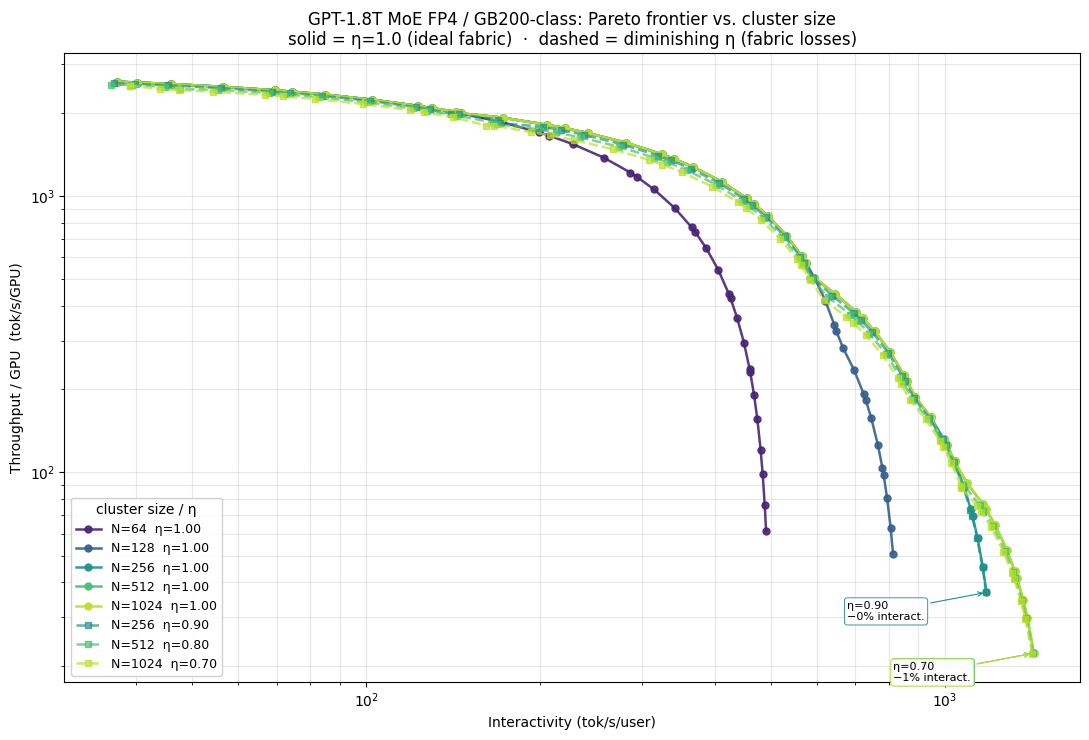

Saved → assets/pareto_vs_cluster_size.png


In [7]:
cmap = plt.get_cmap("viridis")
colors = {N: cmap(0.1 + 0.8 * i / max(1, len(CLUSTER_SIZES) - 1))
          for i, N in enumerate(CLUSTER_SIZES)}

fig, ax = plt.subplots(figsize=(11, 7.5))

# Plot η=1.0 frontiers for ALL cluster sizes (solid lines)
for N in CLUSTER_SIZES:
    fr = frontier_by_N[N]
    if not fr:
        continue
    xs = [p.interactivity for p in fr]
    ys = [p.tput_per_gpu for p in fr]
    ax.plot(xs, ys, "-o", lw=1.8, ms=5, color=colors[N], alpha=0.9,
            label=f"N={N}  η=1.00")

# Overlay η-discounted frontiers as dashed lines (N=256, 512, 1024 only)
for N, eta in ETA_SCHEDULE.items():
    fr = frontier_eta_by_N[N]
    if not fr:
        continue
    xs = [p.interactivity for p in fr]
    ys = [p.tput_per_gpu for p in fr]
    ax.plot(xs, ys, "--s", lw=1.8, ms=5, color=colors[N], alpha=0.7,
            label=f"N={N}  η={eta:.2f}")

    # Annotate the throughput loss at the high-interactivity corner
    top_orig = max(frontier_by_N[N], key=lambda p: p.interactivity)
    top_eta = max(fr, key=lambda p: p.interactivity)
    pct = (1 - top_eta.interactivity / top_orig.interactivity) * 100
    ax.annotate(
        f"η={eta:.2f}\n−{pct:.0f}% interact.",
        xy=(top_eta.interactivity, top_eta.tput_per_gpu),
        xytext=(-100, -20), textcoords="offset points",
        fontsize=8, ha="left",
        bbox=dict(boxstyle="round,pad=0.25", fc="white",
                  ec=colors[N], alpha=0.9, lw=0.7),
        arrowprops=dict(arrowstyle="->", color=colors[N], lw=0.8),
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Interactivity (tok/s/user)")
ax.set_ylabel("Throughput / GPU  (tok/s/GPU)")
ax.set_title(
    "GPT-1.8T MoE FP4 / GB200-class: Pareto frontier vs. cluster size\n"
    "solid = η=1.0 (ideal fabric)  ·  dashed = diminishing η (fabric losses)"
)
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower left", fontsize=9, framealpha=0.9, title="cluster size / η")
fig.tight_layout()
fig.savefig("assets/pareto_vs_cluster_size.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved → assets/pareto_vs_cluster_size.png")

## 8. Cross-model comparison — DeepSeek-R1 on the same cluster-size sweep

The GPT sweep above runs under `PP_MAX = 8`. Both PP and TP have headroom for GPT (`PP ≤ 8` operational cap, `TP ≤ 16` structural), but EP stays at 1 for low-to-mid N because n_experts=16 is small and MoE routing overhead dominates at low B.

**DeepSeek-R1 has a very different lever profile on paper:**

| Parameter       | GPT-1.8T MoE       | DeepSeek-R1          |
|-----------------|--------------------|----------------------|
| L (layers)      | 120                | 61                   |
| Effective PP under cap | 1 ≤ PP ≤ 8 (ladder) | 1 ≤ PP ≤ 8 (ladder) |
| TP range        | 1 … 16 (n_kv=16)   | 1 … 4 (n_kv=5; KV-rep, ladder caps at 4) |
| EP range        | 1 … 16             | 1 … 256              |
| bytes/param     | 0.5 (FP4)          | 1.0 (FP8)            |
| Total params    | 1.8T               | 685B (33B active)    |

A naïve prediction would be that DeepSeek — with EP running up to 256 — scales via EP while GPT scales via PP/TP. **The PP=8 cap brings both models into the same regime**: PP saturates at 8 quickly for both, and the question becomes how each model uses TP / EP / DP for the remaining cluster slots. GPT can grow TP up to 16; DeepSeek's narrow `n_kv=5` caps TP at 4, so its scaling lever past N=128 is necessarily EP. The §8.1 sweep below shows whether the EP-heavy DSR1 frontier matches the unbounded-EP intuition or whether the optimizer still routes around it.

### 8.1 DeepSeek cluster-size sweep


In [8]:
MODEL_DS = "llm_perf/database/model/deepseek_r1_0528.json"
model_ds = load_model_spec(MODEL_DS)

# DeepSeek-R1 partition choices:
#   L=61 is prime -> PP in {1, 61} only (no even splits without uneven partitioning).
#   n_kv=5 strict, but KV replication up to n_q=128 lets TP range freely; cap at 8 for tractability.
#   n_experts=256 -> EP is the primary scaling lever, mirroring PP's role in the GPT sweep.
def enumerate_partitions_ds(n: int) -> list[PartitionSpec]:
    """Local shim for DeepSeek (model_ds, base_system); SP=1 only.

    Constraints inherited from llm_perf/utils/partition_enum.py, with the
    same PP_MAX=8 cap as the GPT sweep:
    PP <= PP_MAX (=8); TP <= min(n_kv=5, n_experts=256) = 5
    (= ladder [1,2,4]); EP <= n_experts=256; TP*EP <= scale_up_domain.
    """
    return _enumerate_partitions(model_ds, base_system, num_devices=n,
                                  pp_max=PP_MAX, sp_choices=[1])


def sweep_partition_ds(system, partition: PartitionSpec) -> list[Point]:
    try:
        mem = compute_memory(model_ds, system, partition, tuner_base)
    except Exception:
        return []
    paging = KVPagingConfig(block_size=16, beam_width=1, system_overhead_GB=1.5)
    kv = compute_kv_paging(model_ds, system, partition, tuner_base, mem, paging)
    b_max = int(kv.max_sequences)
    if b_max < 1:
        return []
    pts: list[Point] = []
    for B in log_spaced_B(b_max):
        tuner = deepcopy(tuner_base)
        tuner.B_decode = B
        try:
            r = InferenceCalculator(model_ds, system, partition, tuner).run()
        except Exception:
            continue
        if r.latency.TPOT <= 0:
            continue
        pts.append(Point(
            N=system.num_devices,
            partition=partition,
            B=B,
            tput_per_gpu=r.latency.TTPS / system.num_devices,
            interactivity=1.0 / r.latency.TPOT,
            TPOT_ms=r.latency.TPOT * 1e3,
        ))
    return pts


# eta = 1.0 baseline.
cloud_by_N_ds: dict[int, list[Point]] = {}
frontier_by_N_ds: dict[int, list[Point]] = {}
for N in CLUSTER_SIZES:
    sys_N = make_system_with_N(N)
    parts = enumerate_partitions_ds(N)
    all_pts: list[Point] = []
    for part in parts:
        all_pts.extend(sweep_partition_ds(sys_N, part))
    fr = pareto_frontier(all_pts)
    cloud_by_N_ds[N] = all_pts
    frontier_by_N_ds[N] = fr
    feasible = len({p.part_label for p in all_pts})
    print(f"N={N:4d}  eta=1.00  partitions(valid)={len(parts):3d}  feasible={feasible:3d}  evals={len(all_pts):5d}  frontier={len(fr):3d}")

# eta-discounted runs at N in {256, 512, 1024}, mirroring the GPT schedule in §7.
cloud_eta_by_N_ds: dict[int, list[Point]] = {}
frontier_eta_by_N_ds: dict[int, list[Point]] = {}
for N, eta in ETA_SCHEDULE.items():
    sys_N = make_system_with_N_eta(N, eta)
    parts = enumerate_partitions_ds(N)
    all_pts: list[Point] = []
    for part in parts:
        all_pts.extend(sweep_partition_ds(sys_N, part))
    fr = pareto_frontier(all_pts)
    cloud_eta_by_N_ds[N] = all_pts
    frontier_eta_by_N_ds[N] = fr
    print(f"N={N:4d}  eta={eta:.2f}  feasible={len({p.part_label for p in all_pts}):3d}  evals={len(all_pts):5d}  frontier={len(fr):3d}")

print("\nWinners per N (DeepSeek-R1, eta=1.0):")
for N in CLUSTER_SIZES:
    counts: dict[str, int] = {}
    for p in frontier_by_N_ds[N]:
        counts[p.part_label] = counts.get(p.part_label, 0) + 1
    ranked = sorted(counts.items(), key=lambda kv: -kv[1])
    print(f"N={N}:")
    for label, cnt in ranked[:5]:
        pd = {kv.split('=')[0]: int(kv.split('=')[1]) for kv in label.split()}
        replica = pd['PP'] * pd['TP'] * pd['EP'] * pd['SP']
        dp = N // replica
        util = dp * replica / N
        print(f"  {label:32s}  x{cnt:<3d}  replica={replica:4d}  DP={dp:3d}  util={util*100:5.1f}%")

N=  64  eta=1.00  partitions(valid)= 84  feasible= 79  evals= 3032  frontier= 46
N= 128  eta=1.00  partitions(valid)=102  feasible= 97  evals= 3785  frontier= 52


N= 256  eta=1.00  partitions(valid)=117  feasible=112  evals= 4431  frontier= 57


N= 512  eta=1.00  partitions(valid)=126  feasible=121  evals= 4829  frontier= 61


N=1024  eta=1.00  partitions(valid)=126  feasible=121  evals= 4829  frontier= 61


N= 256  eta=0.90  feasible=112  evals= 4431  frontier= 56
N= 512  eta=0.80  feasible=121  evals= 4829  frontier= 60


N=1024  eta=0.70  feasible=121  evals= 4829  frontier= 62

Winners per N (DeepSeek-R1, eta=1.0):
N=64:
  PP=8 TP=4 EP=2 SP=1               x25   replica=  64  DP=  1  util=100.0%
  PP=8 TP=4 EP=1 SP=1               x21   replica=  32  DP=  2  util=100.0%
N=128:
  PP=8 TP=4 EP=4 SP=1               x23   replica= 128  DP=  1  util=100.0%
  PP=8 TP=4 EP=1 SP=1               x21   replica=  32  DP=  4  util=100.0%
  PP=8 TP=4 EP=2 SP=1               x8    replica=  64  DP=  2  util=100.0%
N=256:
  PP=8 TP=4 EP=1 SP=1               x21   replica=  32  DP=  8  util=100.0%
  PP=8 TP=4 EP=8 SP=1               x18   replica= 256  DP=  1  util=100.0%
  PP=8 TP=4 EP=4 SP=1               x10   replica= 128  DP=  2  util=100.0%
  PP=8 TP=4 EP=2 SP=1               x8    replica=  64  DP=  4  util=100.0%
N=512:
  PP=8 TP=4 EP=1 SP=1               x21   replica=  32  DP= 16  util=100.0%
  PP=8 TP=4 EP=16 SP=1              x12   replica= 512  DP=  1  util=100.0%
  PP=8 TP=4 EP=8 SP=1               x10 

### 8.2 Side-by-side comparison

Left: GPT-1.8T MoE (re-using §3 data). Right: DeepSeek-R1 on the same cluster sizes. Same fabric, same tuner knobs, ideal scale-up (η=1.0).

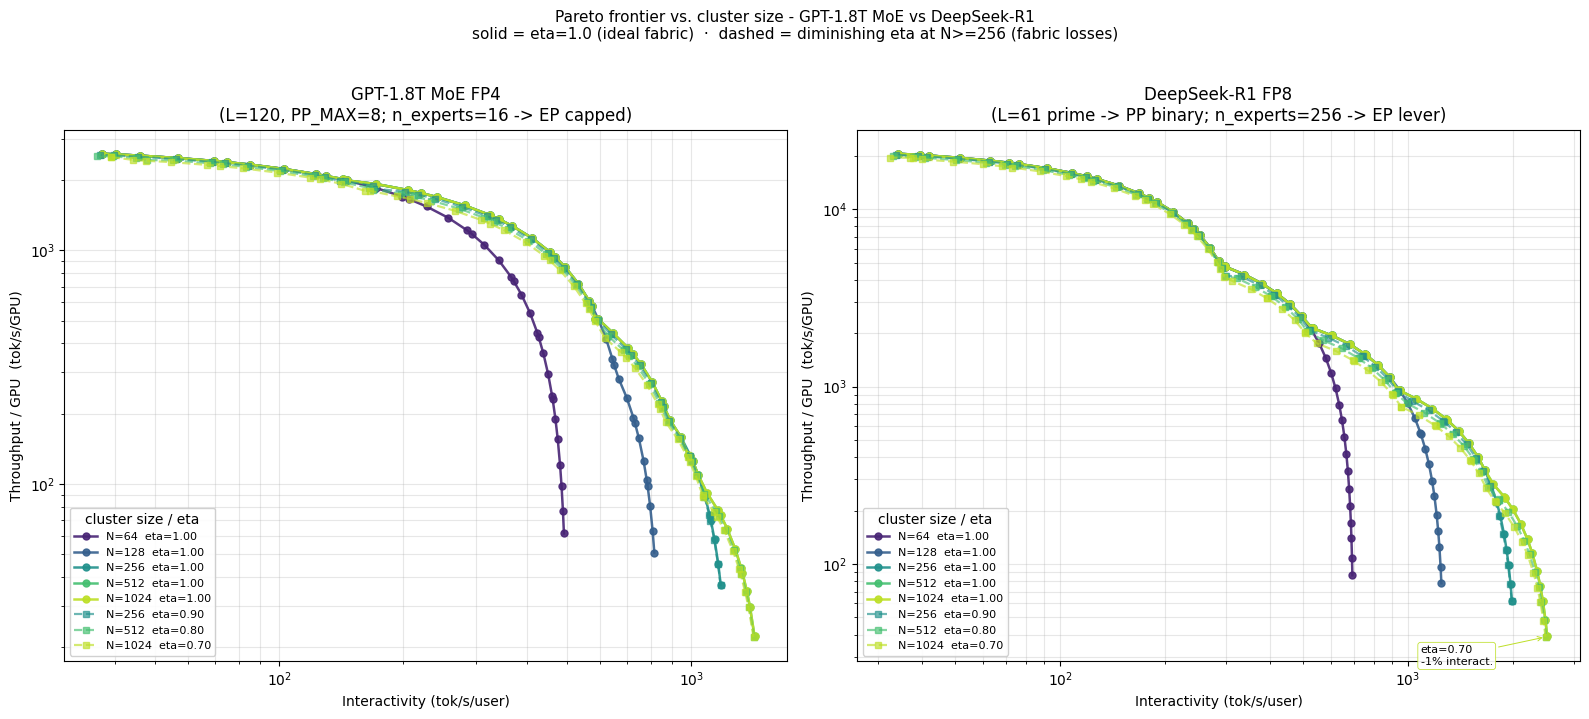

Saved -> assets/pareto_vs_cluster_size_deepseek.png


In [9]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 7))

cmap_cmp = plt.get_cmap("viridis")
colors_cmp = {N: cmap_cmp(0.1 + 0.8 * i / max(1, len(CLUSTER_SIZES) - 1))
              for i, N in enumerate(CLUSTER_SIZES)}

panels = [
    (axL, frontier_by_N,    frontier_eta_by_N,
     "GPT-1.8T MoE FP4\n(L=120, PP_MAX=8; n_experts=16 -> EP capped)"),
    (axR, frontier_by_N_ds, frontier_eta_by_N_ds,
     "DeepSeek-R1 FP8\n(L=61 prime -> PP binary; n_experts=256 -> EP lever)"),
]

for ax, frontiers, frontiers_eta, title in panels:
    # Solid: eta = 1.0 frontiers for every N.
    for N in CLUSTER_SIZES:
        fr = frontiers[N]
        if not fr:
            continue
        ax.plot([p.interactivity for p in fr], [p.tput_per_gpu for p in fr],
                "-o", lw=1.8, ms=5, color=colors_cmp[N], alpha=0.9,
                label=f"N={N}  eta=1.00")

    # Dashed: eta-discounted frontiers at N >= 256 (mirrors the GPT schedule in §7).
    for N, eta in ETA_SCHEDULE.items():
        fr = frontiers_eta.get(N)
        if not fr:
            continue
        ax.plot([p.interactivity for p in fr], [p.tput_per_gpu for p in fr],
                "--s", lw=1.6, ms=5, color=colors_cmp[N], alpha=0.65,
                label=f"N={N}  eta={eta:.2f}")

        # Annotate the interactivity loss at the high-ix corner.
        top_orig = max(frontiers[N], key=lambda p: p.interactivity)
        top_eta  = max(fr,             key=lambda p: p.interactivity)
        pct = (1 - top_eta.interactivity / top_orig.interactivity) * 100
        if pct > 1:
            ax.annotate(
                f"eta={eta:.2f}\n-{pct:.0f}% interact.",
                xy=(top_eta.interactivity, top_eta.tput_per_gpu),
                xytext=(-90, -20), textcoords="offset points",
                fontsize=8, ha="left",
                bbox=dict(boxstyle="round,pad=0.25", fc="white",
                          ec=colors_cmp[N], alpha=0.9, lw=0.6),
                arrowprops=dict(arrowstyle="->", color=colors_cmp[N], lw=0.7),
            )

    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Interactivity (tok/s/user)")
    ax.set_ylabel("Throughput / GPU  (tok/s/GPU)")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="lower left", fontsize=8, framealpha=0.9, title="cluster size / eta", ncol=1)

fig.suptitle(
    "Pareto frontier vs. cluster size - GPT-1.8T MoE vs DeepSeek-R1\n"
    "solid = eta=1.0 (ideal fabric)  ·  dashed = diminishing eta at N>=256 (fabric losses)",
    y=1.02, fontsize=11,
)
fig.tight_layout()
fig.savefig("assets/pareto_vs_cluster_size_deepseek.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved -> assets/pareto_vs_cluster_size_deepseek.png")